# <span style="color:blue">Computer Vision : HW2</span> 

###  <span style="color:blue">Nazhin Nikkhahbahrami 810102530</span>


## <span style="color:red">Part1 : Producing data</span>

### Libraries

In [18]:
import os
import random
import string
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

### 1.1 & 1.2

In [19]:
output_dir = Path("generated_images")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

num_images = 20
text_length = 4
image_size = (200, 80)
background_color = "white"
text_color = "black"

characters = string.ascii_lowercase + string.digits

try:
    font = ImageFont.truetype("arial.ttf", 44)
except:
    font = ImageFont.load_default()

data = []

for i in range(1, num_images + 1):
    text = ''.join(random.choices(characters, k=text_length))
    
    img = Image.new("RGB", image_size, background_color)
    draw = ImageDraw.Draw(img)
    
    start_x = random.randint(15, 30)
    
    for char in text:
        y = random.randint(10, 25)
        draw.text((start_x, y), char, fill=text_color, font=font)
        
        bbox = draw.textbbox((0, 0), char, font=font)
        char_width = bbox[2] - bbox[0]
        
        start_x += char_width + random.randint(0, 5)
        
    filename = f"image_{i:02d}_{text}.png"
    filepath = output_dir / filename
    
    img.save(filepath)
    
    data.append({
        "image_name": filename,
        "text": text
    })

df = pd.DataFrame(data)
df.to_csv(output_dir / "labels.csv", index=False)

Preventing Character Overlap:

When generating words, we accurately calculated the width of each character using its bounding box. The next character was placed based on this width plus a small random gap. This prevents characters from overlapping, which makes the segmentation step much easier and more accurate.

Displaying :

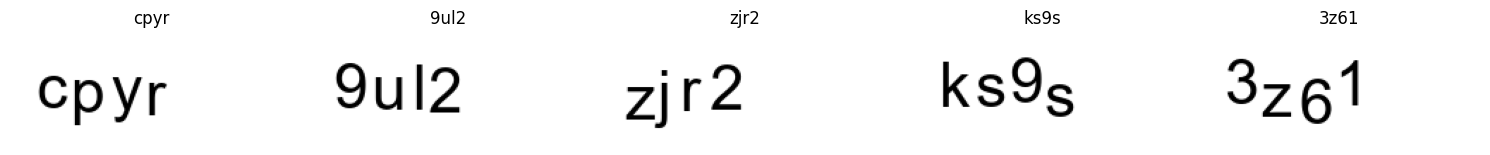

In [20]:
output_dir = Path("generated_images")
image_paths = list(output_dir.glob("*.png"))[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, img_path in zip(axes, image_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.stem.split('_')[-1])
    ax.axis('off')

plt.tight_layout()
plt.show()

### 1.3

Adding salt & pepper noise

In [21]:
input_dir = Path("generated_images")
output_dir = Path("noisy_images")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

def add_salt_pepper_noise(image, amount=0.05, salt_vs_pepper=0.5):
    img_array = np.array(image).copy()
    
    h, w, c = img_array.shape
    num_noise = int(amount * h * w)

    num_salt = int(num_noise * salt_vs_pepper)
    coords_salt = [np.random.randint(0, i, num_salt) for i in (h, w)]
    img_array[coords_salt[0], coords_salt[1], :] = 255

    num_pepper = num_noise - num_salt
    coords_pepper = [np.random.randint(0, i, num_pepper) for i in (h, w)]
    img_array[coords_pepper[0], coords_pepper[1], :] = 0

    return Image.fromarray(img_array)

for image_path in input_dir.glob("*.png"):
    img = Image.open(image_path).convert("RGB")
    noisy_img = add_salt_pepper_noise(img, amount=0.08, salt_vs_pepper=0.5)
    
    noisy_filename = f"noisy_{image_path.name}"
    noisy_img.save(output_dir / noisy_filename)

print("All noisy images saved in 'noisy_images' folder.")

All noisy images saved in 'noisy_images' folder.


Displaying :

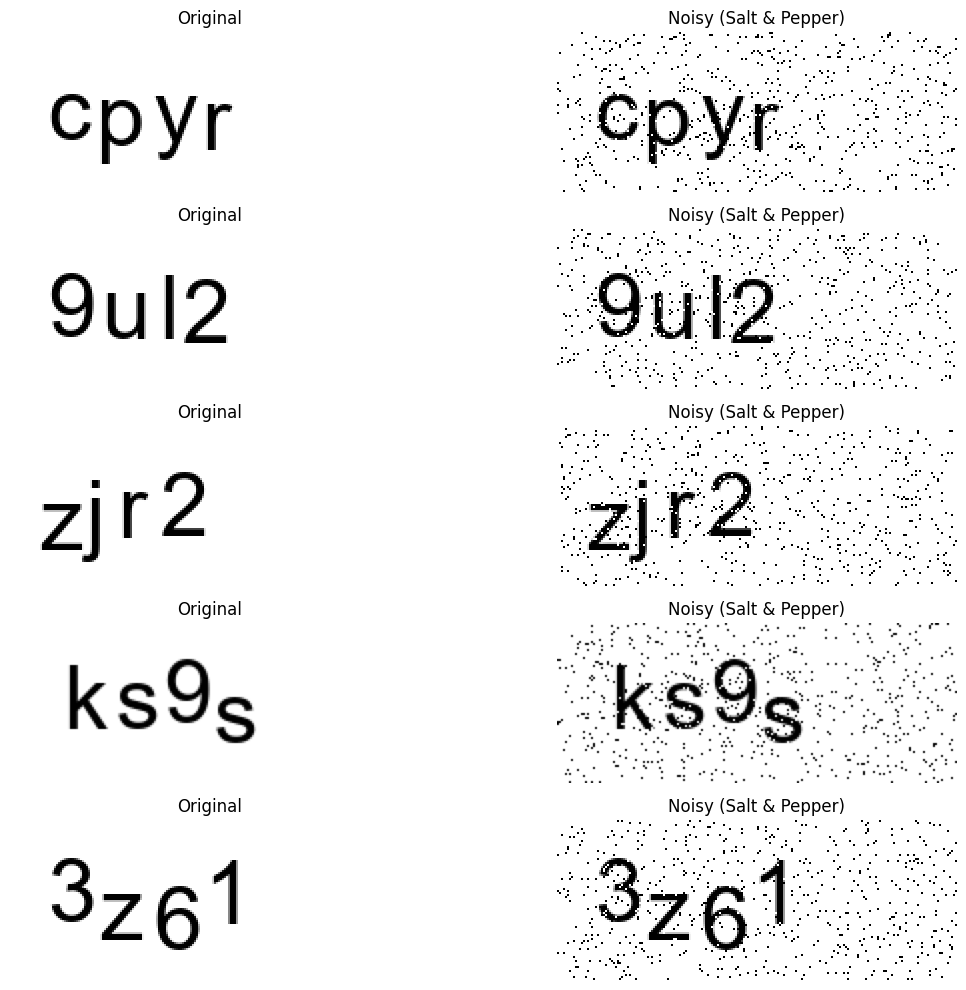

In [22]:
original_dir = Path("generated_images")
noisy_dir = Path("noisy_images")

original_paths = list(original_dir.glob("*.png"))[:5]

fig, axes = plt.subplots(5, 2, figsize=(12, 10))

for i, orig_path in enumerate(original_paths):
    noisy_path = noisy_dir / f"noisy_{orig_path.name}"
    
    orig_img = Image.open(orig_path)
    noisy_img = Image.open(noisy_path)
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(noisy_img)
    axes[i, 1].set_title("Noisy (Salt & Pepper)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

After adding salt-and-pepper noise, random black and white pixels appear over the original images.

The characters are still recognizable, but the image quality is reduced because the noise introduces unwanted pixel disturbances.

In these results, black dots are more visible than white dots because the background of the images is already white.

Therefore, the white noise blends with the background, while the black noise stands out clearly.

Overall, salt-and-pepper noise decreases image clarity and can make character recognition more difficult, especially if the noise level increases.

### 1.4

##### Reason for Using Median Filter :

In this project, the median filter was used because it is very effective for removing salt-and-pepper noise.

This type of noise appears as random black and white pixels, and the median filter can reduce these noisy pixels while preserving the edges of the characters better than many other smoothing filters.

Unlike mean or averaging filters, the median filter does not simply blur the image.

Instead, it replaces each pixel with the median value of its neighboring pixels, which helps remove isolated noise points without significantly damaging the shape of the letters and digits.

Therefore, the median filter is a suitable choice for this task because it improves image quality and keeps the characters more readable after noise removal.


3x3 is appropriate but if the noise is more then this 5x5 is used.

Showing the result and comparing :

In [23]:
input_dir = Path("noisy_images")
output_dir = Path("filtered_images")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

kernel_size = 3

for image_path in input_dir.glob("*.png"):
    img = Image.open(image_path).convert("RGB")
    filtered_img = img.filter(ImageFilter.MedianFilter(size=kernel_size))
    output_path = output_dir / f"filtered_{image_path.name}"
    filtered_img.save(output_path)

print("All filtered images saved in 'filtered_images' folder.")

All filtered images saved in 'filtered_images' folder.


Displaying :

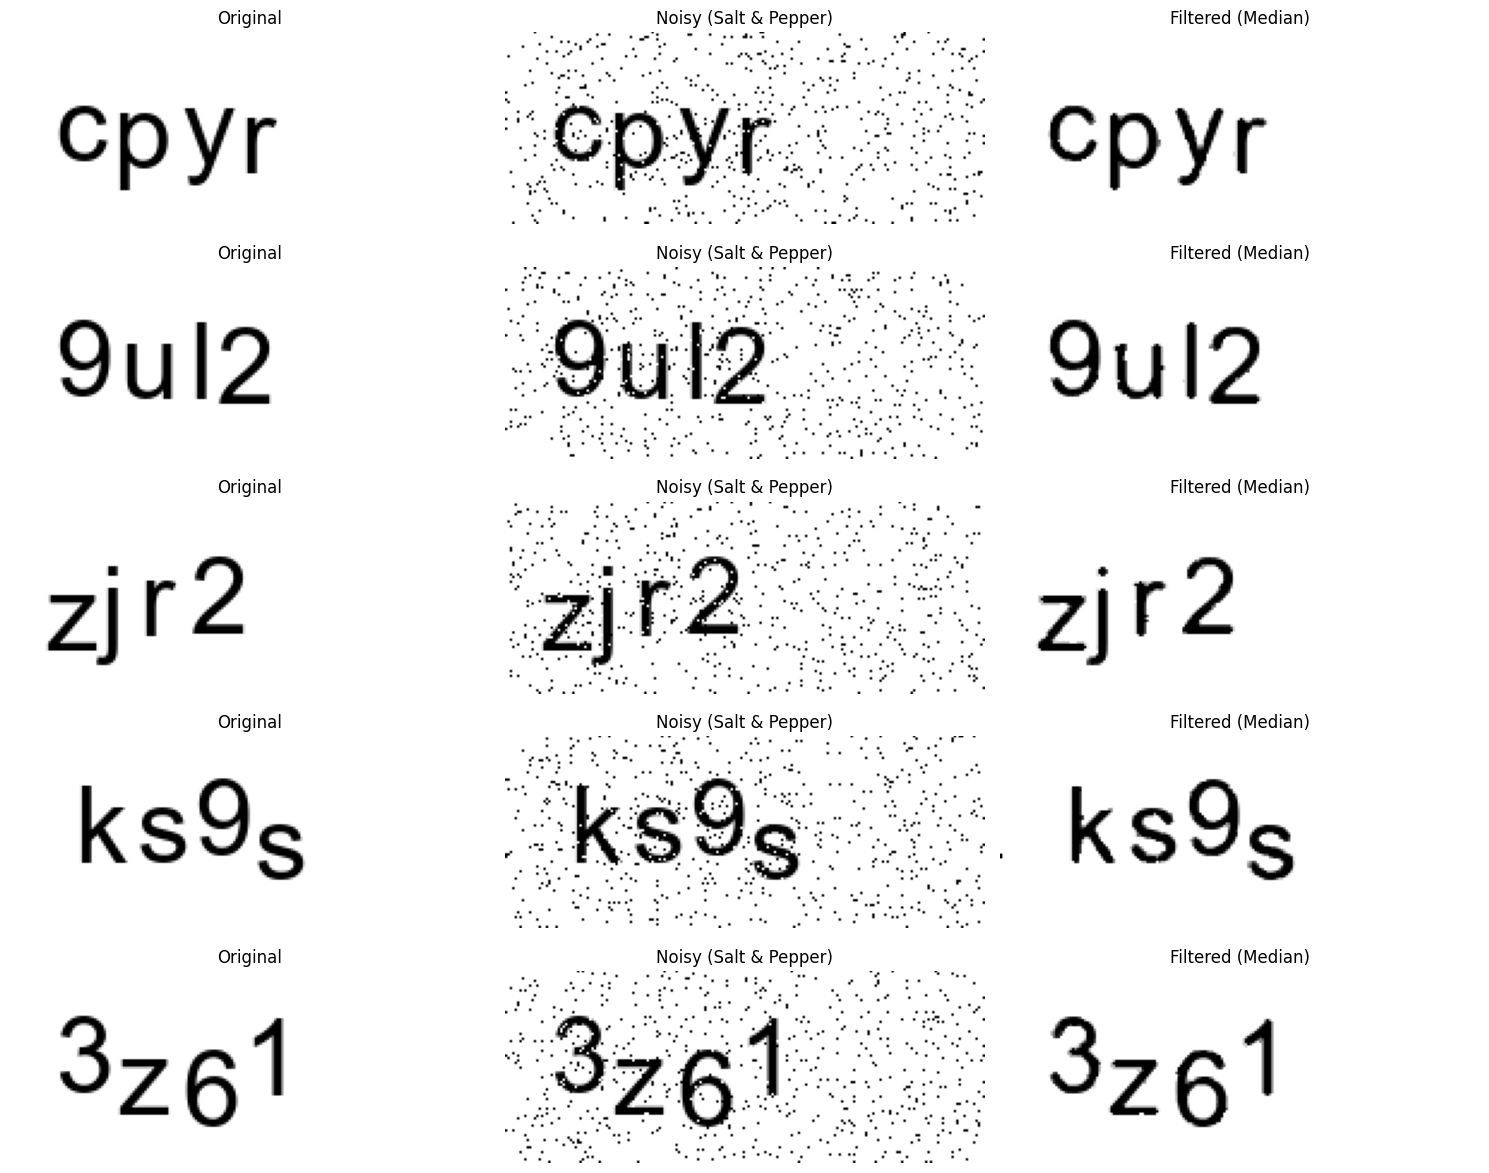

In [24]:
original_dir = Path("generated_images")
noisy_dir = Path("noisy_images")
filtered_dir = Path("filtered_images")

original_paths = list(original_dir.glob("*.png"))[:5]

fig, axes = plt.subplots(5, 3, figsize=(15, 12))

for i, orig_path in enumerate(original_paths):
    noisy_path = noisy_dir / f"noisy_{orig_path.name}"
    filtered_path = filtered_dir / f"filtered_{noisy_path.name}"
    
    orig_img = Image.open(orig_path)
    noisy_img = Image.open(noisy_path)
    filtered_img = Image.open(filtered_path)
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(noisy_img)
    axes[i, 1].set_title("Noisy (Salt & Pepper)")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(filtered_img)
    axes[i, 2].set_title("Filtered (Median)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

The results show that the median filter was effective in reducing salt-and-pepper noise from the images.

Compared to the noisy images, the filtered images contain much fewer random black pixels and the characters are clearer and easier to read.

Another important observation is that the median filter removes most of the isolated noise while preserving the main shape and edges of the letters and digits.

This is important because the readability of the text must be maintained after filtering.

Overall, the median filter is a suitable choice for this task because it improves image quality and reduces noise without causing excessive blur.



## <span style="color:red">Part2 : Pre-processing the datas</span>

### 2.1

#### Why do blurring filters reduce noise?

Blurring filters reduce noise by smoothing sudden intensity changes between neighboring pixels.

Noise usually appears as rapid and irregular pixel variations, while important image structures often change more gradually over space.

When a blur filter is applied, each pixel is replaced by a weighted combination of its neighboring pixels.

As a result, extreme pixel values caused by noise are averaged out, and the image becomes smoother.

The disadvantage is that blur filters do not only reduce noise; they can also weaken fine details and edges.

Therefore, there is always a trade-off between noise removal and image sharpness.

### Using another type of filter :

The Gaussian filter is used to reduce noise by smoothing the image.

It works by replacing each pixel with a weighted average of nearby pixels.

In this filter, closer pixels have more effect than farther pixels, so the smoothing is more natural than a simple average filter.

It helps reduce random noise and makes the image cleaner.

However, since it blurs the image, some edges and small details may become weaker.

In [25]:
input_dir = Path("noisy_images")
output_dir = Path("gaussian_filtered_images")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

kernel_values = [
    1, 4, 7, 4, 1,
    4, 16, 26, 16, 4,
    7, 26, 41, 26, 7,
    4, 16, 26, 16, 4,
    1, 4, 7, 4, 1
]
scale_value = 273

for image_path in input_dir.glob("*.png"):
    img = Image.open(image_path).convert("RGB")

    filtered_img = img.filter(ImageFilter.Kernel(
        size=(5, 5),
        kernel=kernel_values,
        scale=scale_value
    ))

    output_path = output_dir / f"gaussian_{image_path.name}"
    filtered_img.save(output_path)

print("All stronger Gaussian-filtered images saved in 'gaussian_filtered_images' folder.")

All stronger Gaussian-filtered images saved in 'gaussian_filtered_images' folder.


Dispalying & Comparing :

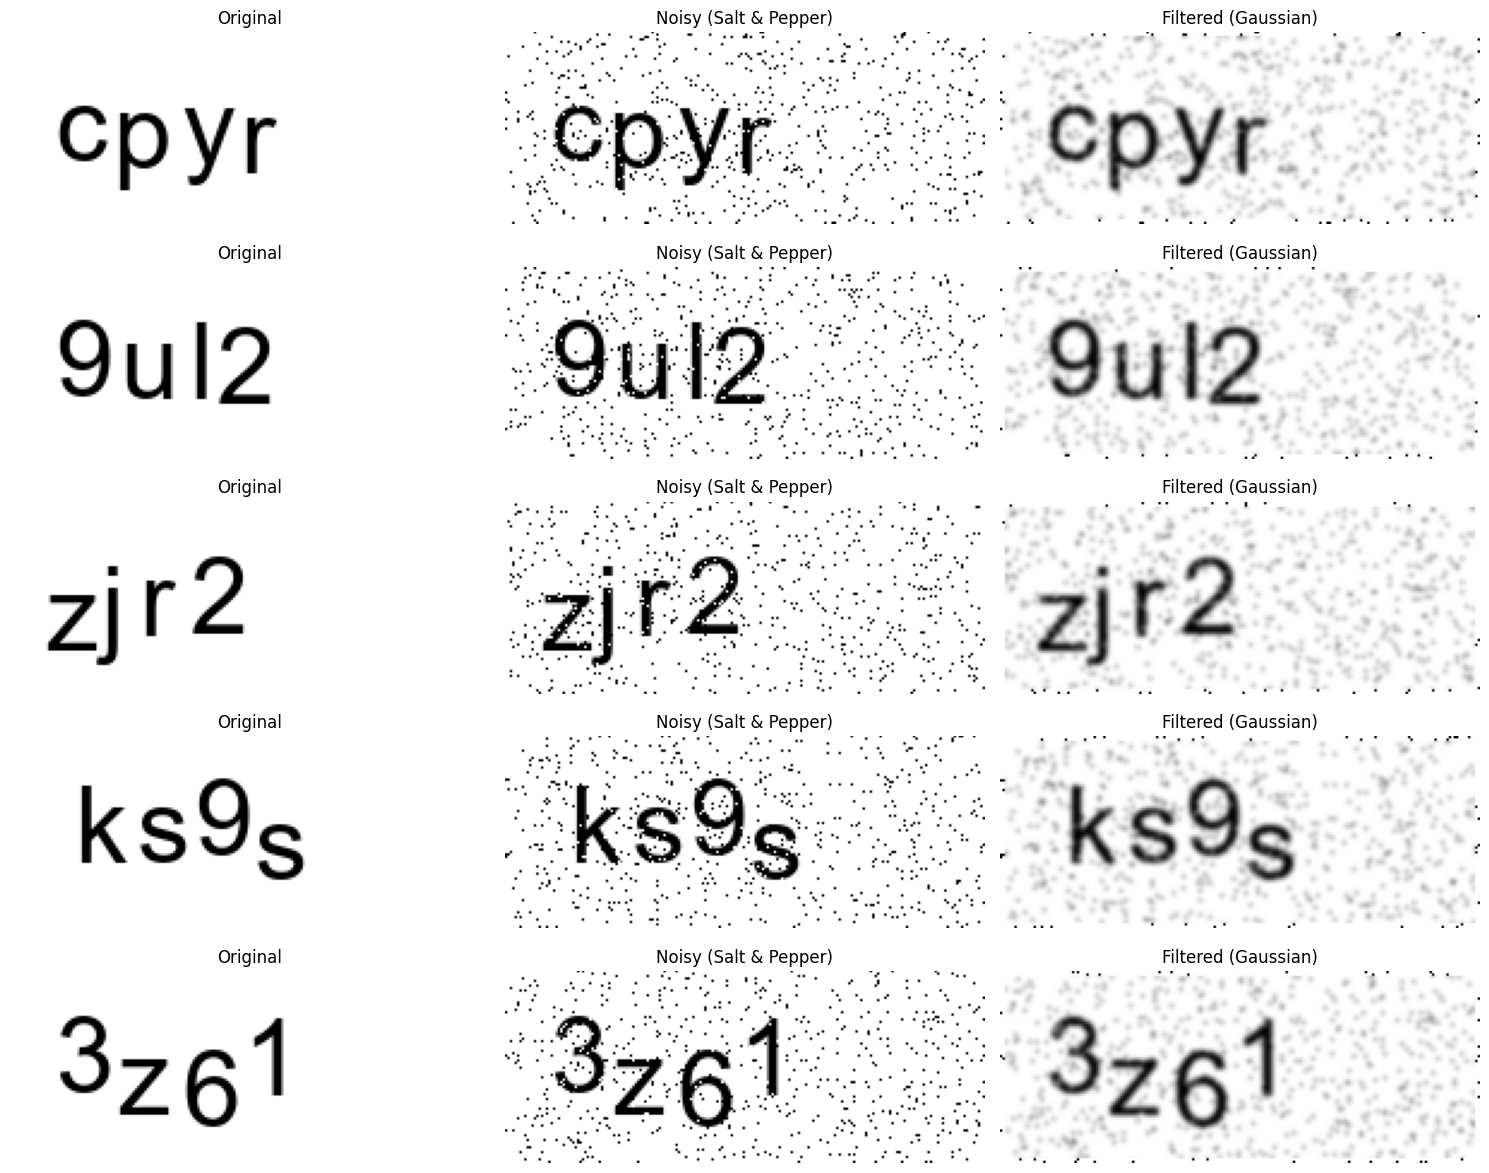

In [26]:
original_dir = Path("generated_images")
noisy_dir = Path("noisy_images")
gaussian_dir = Path("gaussian_filtered_images")

original_paths = list(original_dir.glob("*.png"))[:5]

fig, axes = plt.subplots(5, 3, figsize=(15, 12))

for i, orig_path in enumerate(original_paths):
    noisy_path = noisy_dir / f"noisy_{orig_path.name}"
    gaussian_path = gaussian_dir / f"gaussian_{noisy_path.name}"
    
    orig_img = Image.open(orig_path)
    noisy_img = Image.open(noisy_path)
    gaussian_img = Image.open(gaussian_path)
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(noisy_img)
    axes[i, 1].set_title("Noisy (Salt & Pepper)")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(gaussian_img)
    axes[i, 2].set_title("Filtered (Gaussian)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

Salt-and-pepper noise is an impulse type of noise, which means some pixels suddenly become very dark or very bright.

The Gaussian filter works based on weighted averaging. Therefore, it only spreads and blurs these corrupted pixels instead of completely removing them.

### 2.2

#### Sharpening

Sharpening is a technique used to make edges and fine details more visible in an image. It increases the contrast around boundaries, so blurred objects appear clearer and more distinct. Sharpening does not truly recover lost information, but it improves the visual appearance of the image.

#### De-blurring

De-blurring refers to methods that try to restore an image that has become blurry due to smoothing, motion, or defocus. These methods attempt to reverse the blur effect and recover sharper structures. In practice, de-blurring can improve image quality, but it may also amplify noise if not applied carefully.

Although the median filter is highly effective at removing salt-and-pepper noise while preserving the general shape of the characters, it inevitably causes a slight softening and blurring of the character edges. In the context of OCR, sharp and distinct edges are crucial for accurate character segmentation. Therefore, the Sharpening filter was applied to the median-filtered images to eliminate this induced blur, enhance edge contrast, and restore the crispness of the letters and digits without amplifying the original noise.

In this project, Sharpening was selected over De-blurring for the following reasons:

Any noise removal filter makes the image slightly soft. We applied a sharpening filter to make the edges of the characters clear again. This is very important for the contour detection step.

Sufficient Edge Enhancement: Since the main goal is character extraction and recognition (OCR), precisely recovering lost pixel information is unnecessary. Simply increasing the contrast along the edges of the characters is enough to separate them clearly from the background.

Avoiding Noise Amplification: De-blurring techniques carry a high risk of amplifying any residual noise left from the previous filtering stages. This amplified noise could severely disrupt the subsequent segmentation process.


### The method :

In [27]:
input_dir = Path("filtered_images")
output_dir = Path("sharpened_images")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

for img_path in input_dir.glob("*.png"):
    img = cv2.imread(str(img_path))
    
    sharpened = cv2.filter2D(img, -1, sharpen_kernel)
    
    output_path = output_dir / f"sharpened_{img_path.name}"
    cv2.imwrite(str(output_path), sharpened)

print("Sharpened images saved.")

Sharpened images saved.


Display :

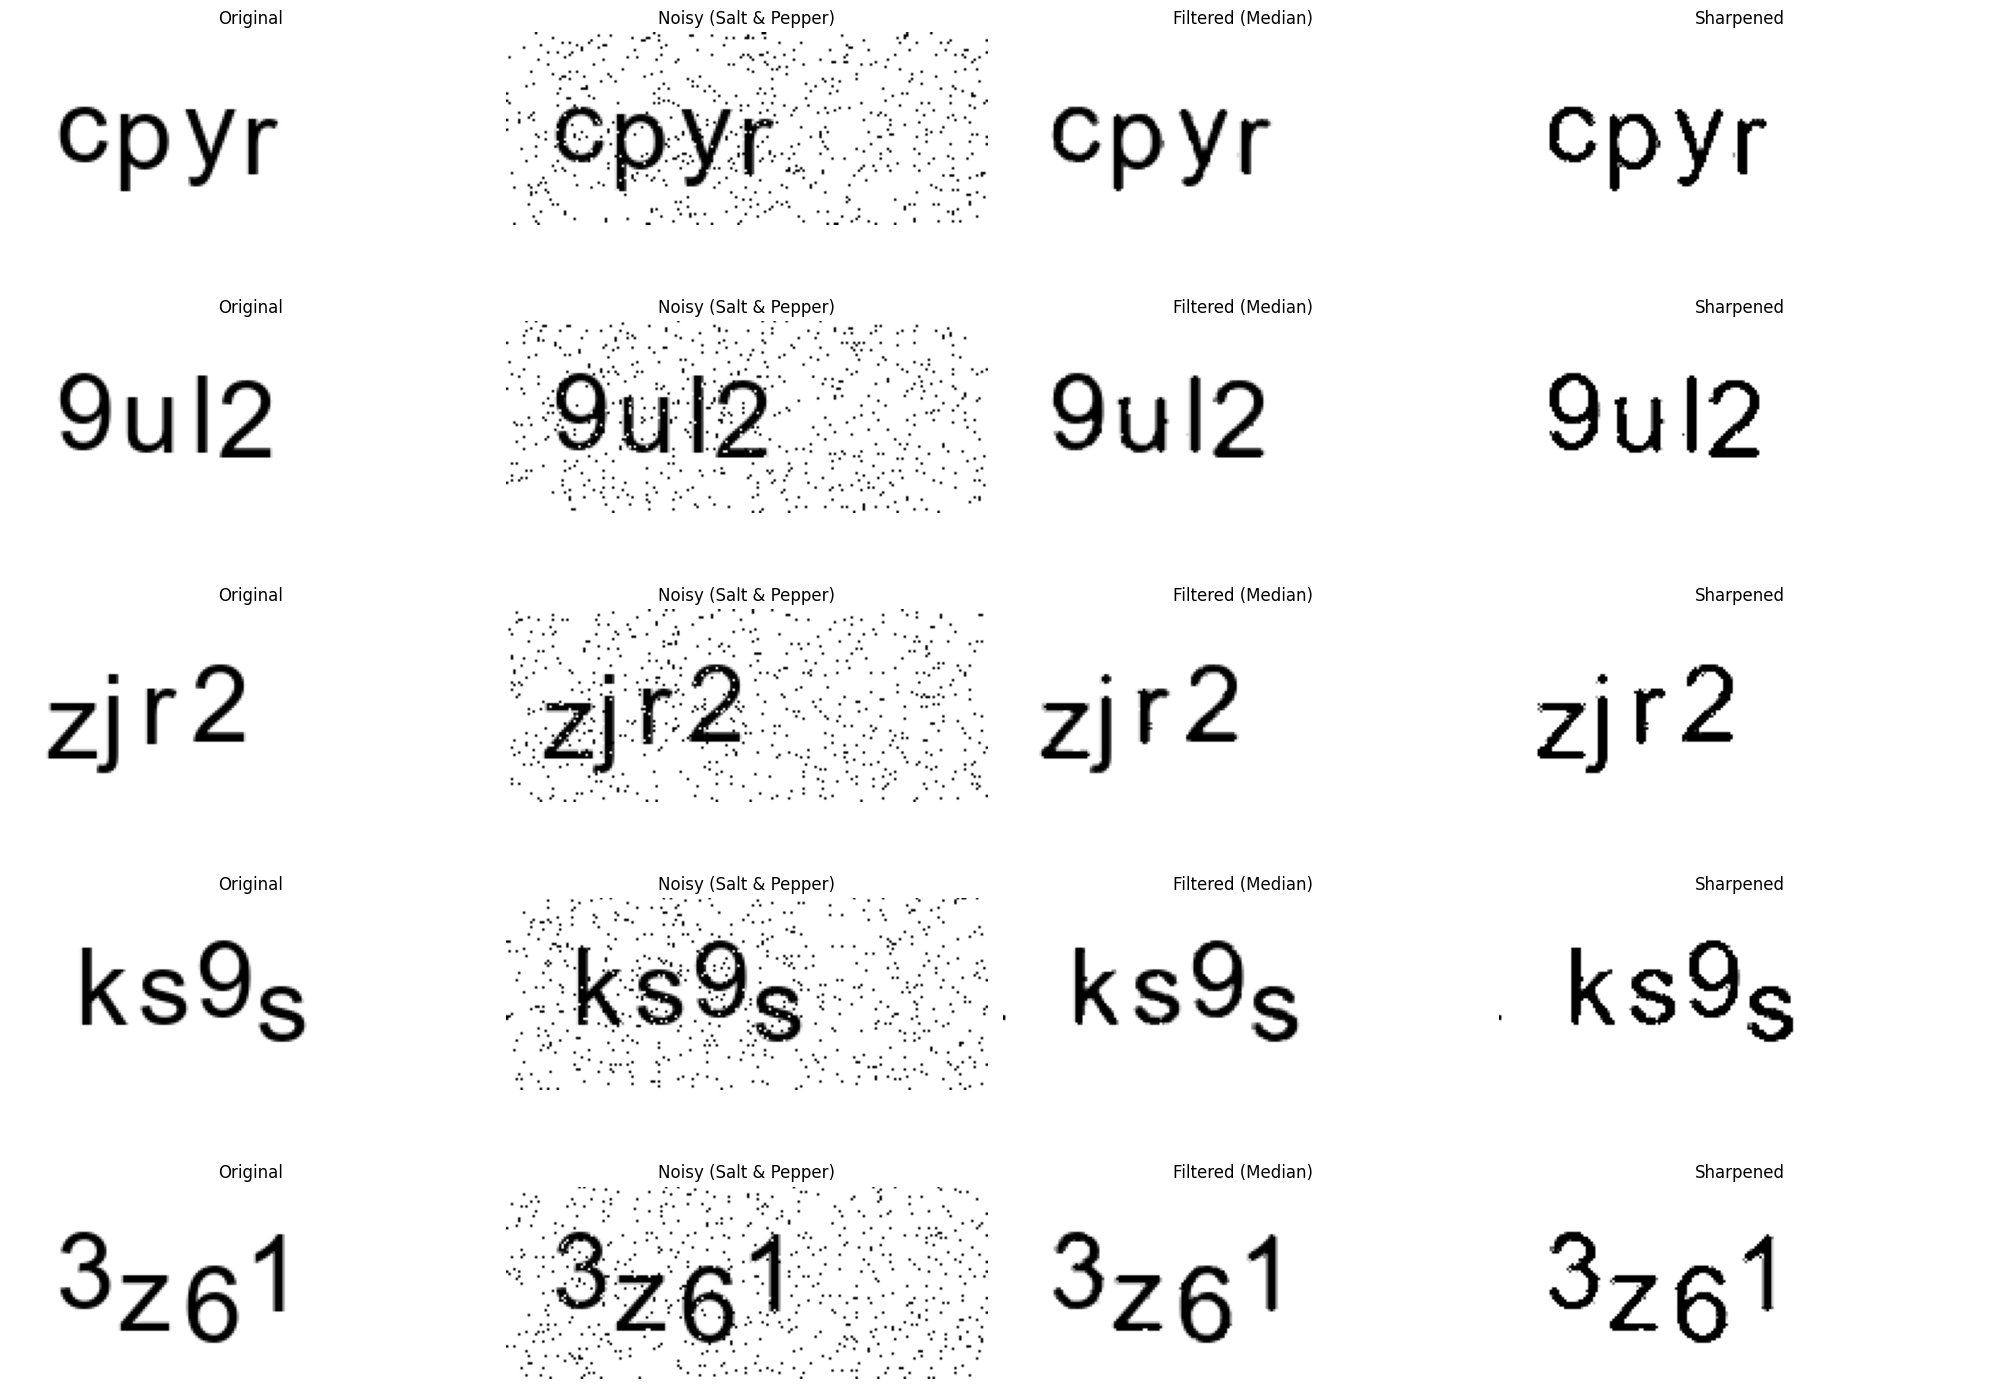

In [28]:
original_dir = Path("generated_images")
noisy_dir = Path("noisy_images")
filtered_dir = Path("filtered_images")
sharpened_dir = Path("sharpened_images")

original_paths = list(original_dir.glob("*.png"))[:5]

fig, axes = plt.subplots(5, 4, figsize=(20, 15))

for i, orig_path in enumerate(original_paths):
    noisy_name = f"noisy_{orig_path.name}"
    filtered_name = f"filtered_{noisy_name}"
    sharpened_name = f"sharpened_{filtered_name}"
    
    noisy_path = noisy_dir / noisy_name
    filtered_path = filtered_dir / filtered_name
    sharpened_path = sharpened_dir / sharpened_name
    
    orig_img = Image.open(orig_path)
    noisy_img = Image.open(noisy_path)
    filtered_img = Image.open(filtered_path)
    sharpened_img = Image.open(sharpened_path)
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(noisy_img)
    axes[i, 1].set_title("Noisy (Salt & Pepper)")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(filtered_img)
    axes[i, 2].set_title("Filtered (Median)")
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(sharpened_img)
    axes[i, 3].set_title("Sharpened")
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

The visual changes after applying the Sharpening filter are subtle because the images already have high contrast (black text on a white background). However, this filter successfully removes the soft, gray edge pixels (caused by the blurring effect of the median filter) and pushes them toward absolute black and white. As a result, the character boundaries become crisper and more precise without generating destructive noise. This clarity is absolutely essential for higher accuracy in the critical segmentation stage.

### 2.3

### Treshold method

In this method, the threshold value refers to the minimum area (number of connected pixels) required for a component to remain in the image. If a connected blob of pixels has an area smaller than this threshold, it is considered noise and gets removed.The threshold value is not fixed. It depends heavily on the characteristics of the images, such as the image resolution, the font size of the text, and the size of the noise spots. For example, if the image resolution or font size increases, the threshold must also be increased. The value must be carefully tuned to remove noise without accidentally deleting small but valid parts of the characters, such as the dot on the letter 'i' or 'j'.

In [29]:
input_dir = Path("sharpened_images")
output_dir = Path("binary_cleaned_images")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

size_threshold = 10

for img_path in input_dir.glob("*.png"):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    binary = 255 - binary
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    cleaned = np.zeros_like(binary)
    
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= size_threshold:
            cleaned[labels == i] = 255
            
    result = cv2.bitwise_not(cleaned)
    
    out_path = output_dir / f"cleaned_{img_path.name}"
    cv2.imwrite(str(out_path), result)

print("Binary cleaned images saved in 'binary_cleaned_images' folder.")

Binary cleaned images saved in 'binary_cleaned_images' folder.


Displaying :

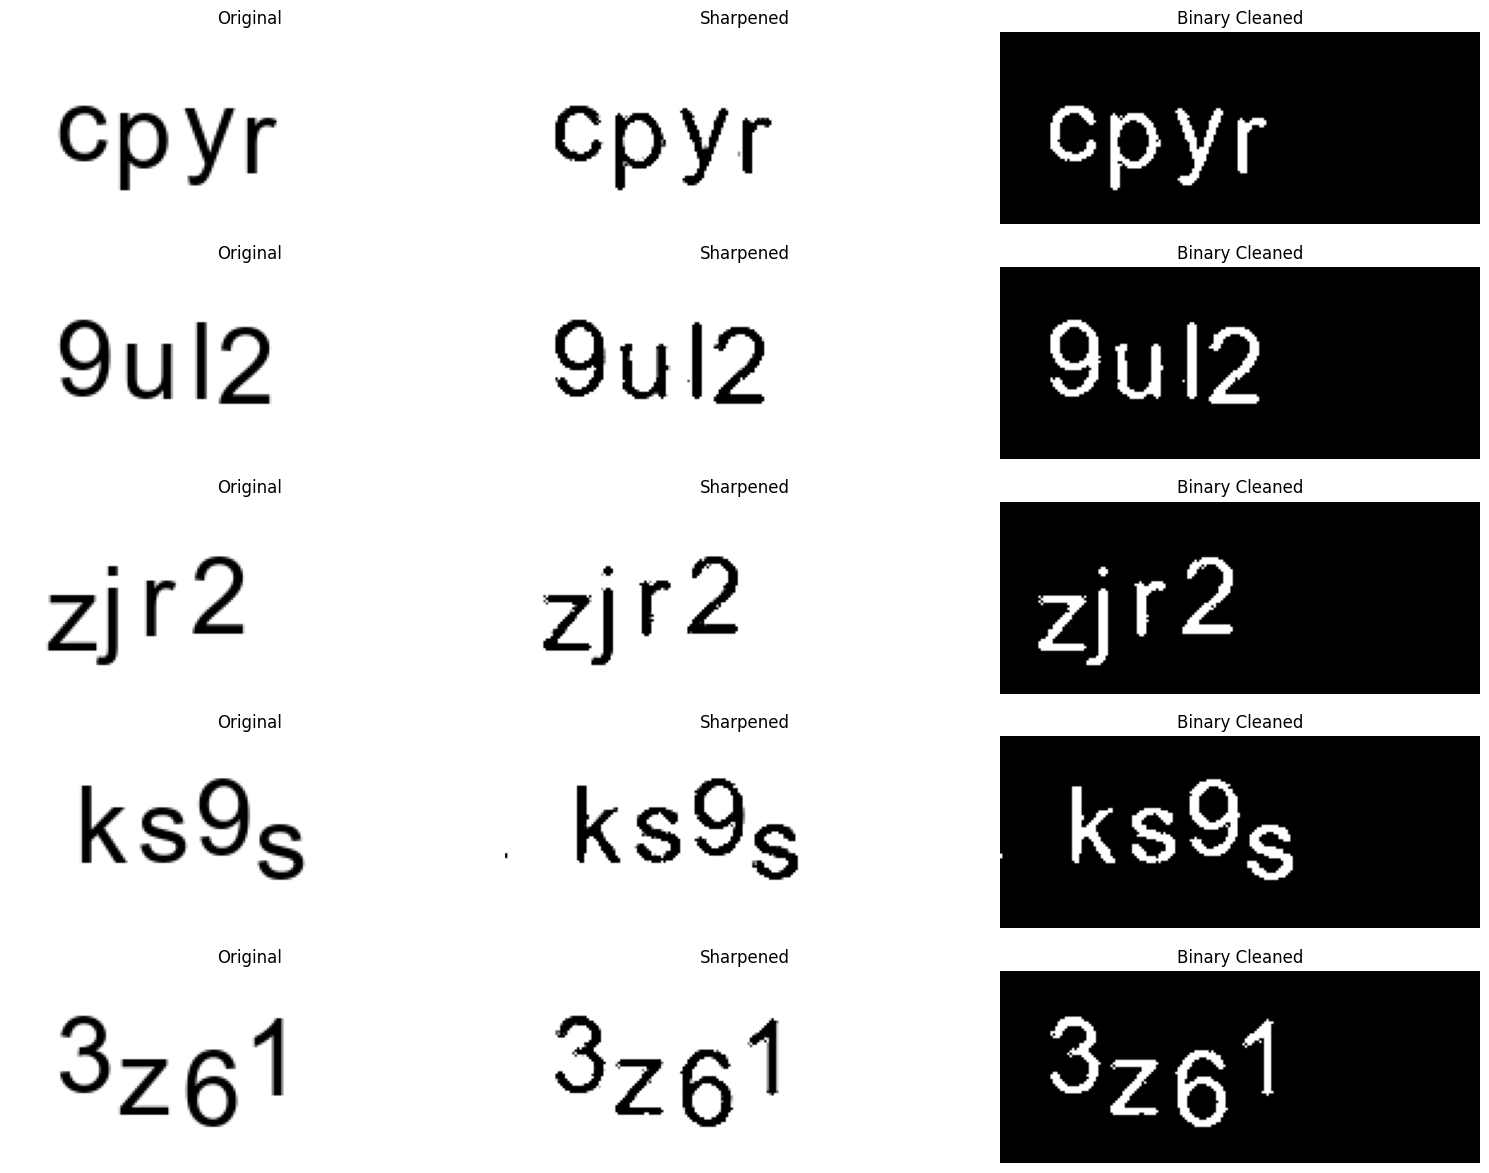

In [30]:
original_dir = Path("generated_images")
sharpened_dir = Path("sharpened_images")
cleaned_dir = Path("binary_cleaned_images")

original_paths = sorted(list(original_dir.glob("*.png")))[:5]

fig, axes = plt.subplots(5, 3, figsize=(15, 12))

for i, orig_path in enumerate(original_paths):
    sharpened_name = f"sharpened_filtered_noisy_{orig_path.name}"
    cleaned_name = f"cleaned_{sharpened_name}"
    
    sharpened_path = sharpened_dir / sharpened_name
    cleaned_path = cleaned_dir / cleaned_name
    
    orig_img = Image.open(orig_path)
    sharpened_img = Image.open(sharpened_path)
    cleaned_img = Image.open(cleaned_path)
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(sharpened_img)
    axes[i, 1].set_title("Sharpened")
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(cleaned_img, cmap='gray')
    axes[i, 2].set_title("Binary Cleaned")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

During the connected component removal phase, the size threshold plays a critical role. Initially, a threshold of 25 pixels was applied. While it successfully cleared the background noise, it mistakenly removed the dots above the letters 'i' and 'j', treating them as noise due to their small area.
To resolve this issue, the threshold was lowered to 10 pixels. This adjustment created the optimal balance: the threshold is now small enough to preserve valid, tiny character features (like the dots), yet large enough to effectively eliminate the remaining isolated noise components. This demonstrates that the threshold is not a fixed universal value, but a hyperparameter that must be carefully tuned according to the specific characteristics of the dataset.

## <span style="color:red">Part3 : Segmentation</span>

### 3.1

In [31]:
input_dir = Path("binary_cleaned_images")
output_dir = Path("segmented_characters")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

for img_path in input_dir.glob("*.png"):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    
    kernel = np.ones((15, 1), np.uint8)
    connected = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    bounding_boxes = [cv2.boundingRect(c) for c in contours]
    bounding_boxes = sorted(bounding_boxes, key=lambda b: b[0])
    
    valid_boxes = [box for box in bounding_boxes if box[2] > 5 and box[3] > 10]
    
    print(f"Image: {img_path.name} -> Extracted characters: {len(valid_boxes)}")
    
    for idx, (x, y, w, h) in enumerate(valid_boxes):
        char_crop = img[y:y+h, x:x+w]
        
        out_name = f"{img_path.stem}_char_{idx+1}.png"
        cv2.imwrite(str(output_dir / out_name), char_crop)

Image: cleaned_sharpened_filtered_noisy_image_01_cpyr.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_02_9ul2.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_03_zjr2.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_04_ks9s.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_05_3z61.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_06_ow87.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_07_dzkq.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_08_3w7y.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_09_jec8.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_10_bhbu.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_11_6209.png -> Extracted characters: 1
Image: cleaned_sharpened_filtered_noisy_image_12_heif.png -> Extr

Because of the noise, touching characters or similarities between some characters(like: 0,o-9,q-i,j-8,s ...) the result is not satisfactory.This can disturb the segmentation or accuracy we want.

In [32]:
input_dir = Path("binary_cleaned_images")
output_dir = Path("segmented_characters_corrected")
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

MIN_AREA = 10
MERGE_THRESHOLD = 1

def find_boxes(bin_img):
    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w * h >= MIN_AREA:
            boxes.append((x, y, w, h))
    boxes.sort(key=lambda b: b[0])
    return boxes

def merge_bounding_boxes(boxes, threshold=MERGE_THRESHOLD):
    merged_boxes = []
    for i in range(len(boxes)):
        if not merged_boxes:
            merged_boxes.append(boxes[i])
        else:
            x1, y1, w1, h1 = merged_boxes[-1]
            x2, y2, w2, h2 = boxes[i]

            right1 = x1 + w1
            right2 = x2 + w2

            if abs(right1 - right2) <= threshold:
                new_box = (
                    min(x1, x2),
                    min(y1, y2),
                    max(x1 + w1, x2 + w2) - min(x1, x2),
                    max(y1 + h1, y2 + h2) - min(y1, y2)
                )
                merged_boxes[-1] = new_box
            else:
                merged_boxes.append(boxes[i])
    return merged_boxes

for img_path in input_dir.glob("*.png"):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    if np.mean(img) > 127:
        _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    else:
        _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    boxes = find_boxes(binary)
    merged_boxes = merge_bounding_boxes(boxes, threshold=MERGE_THRESHOLD)

    print(f"Image: {img_path.name} -> Extracted characters: {len(merged_boxes)}")

    for idx, (x, y, w, h) in enumerate(merged_boxes):
        char_crop = img[y:y+h, x:x+w]
        
        out_name = f"segmented_{img_path.stem}_char_{idx+1}.png"
        cv2.imwrite(str(output_dir / out_name), char_crop)

Image: cleaned_sharpened_filtered_noisy_image_01_cpyr.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_02_9ul2.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_03_zjr2.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_04_ks9s.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_05_3z61.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_06_ow87.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_07_dzkq.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_08_3w7y.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_09_jec8.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_10_bhbu.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_11_6209.png -> Extracted characters: 4
Image: cleaned_sharpened_filtered_noisy_image_12_heif.png -> Extr

### 3.2

Keeping Character Order: > The cv2.findContours function does not always return characters from left to right. To fix this, we sorted the bounding boxes based on their X-coordinates. This ensures the characters are extracted in the correct order to form the word.

Filtering Bad Contours: > Sometimes, connected noise pixels look like small letters. We filtered out these very small areas to make the system more robust and ignore the remaining noise.

In [33]:
input_dir = Path("segmented_characters_corrected")
output_dir = Path("final_resized_characters")

if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)

TARGET_SIZE = (64, 64)

for img_path in input_dir.glob("*.png"):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    
    resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    
    out_name = f"final_64x64_{img_path.name}"
    cv2.imwrite(str(output_dir / out_name), resized)

## <span style="color:red">Part4 : Characters Recognition</span>

### 4.1 & 4.2

In the last part of the project, we use a template matching method to recognize the separated characters. First, we load the standard font images (from the Mapset folder), change them to grayscale, and resize them to exactly 64x64 pixels. An important step here is adding a black border (zero-padding) of 8 pixels around each reference character, which makes their size 80x80 pixels. This extra space is very helpful because it allows the system to handle small shifts or errors in how the characters were cut.

To recognize a letter, we resize each separated character from our images to 64x64 pixels. This image becomes our "template". The program then compares this template with all the 80x80 reference images using OpenCV's cv2.matchTemplate function (using the TM_CCOEFF_NORMED method). This method checks how similar the shapes are, ignoring simple changes in brightness.

For every comparison, we find the highest match score. The reference letter that gets the best score is chosen as our final prediction. In the end, we extract the true letters from the file names to calculate the total accuracy of our system. All the predictions and their scores are then saved in a CSV file for review.

In [34]:
segmented_dir = Path("final_resized_characters")
mapset_dir = Path("Mapset")

mapset = {}
for file in mapset_dir.glob("*.png"):
    img = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (64, 64))
        padded_ref = cv2.copyMakeBorder(img, 8, 8, 8, 8, cv2.BORDER_CONSTANT, value=0)
        mapset[file.stem] = padded_ref

results = []
correct = 0
all_segs = sorted(list(segmented_dir.glob("*.png")))

for seg_path in all_segs:
    segment = cv2.imread(str(seg_path), cv2.IMREAD_GRAYSCALE)
    if segment is None: 
        continue
    
    segment = cv2.resize(segment, (64, 64))
    
    best_label = ""
    best_corr = -1.0
    
    for label, padded_ref in mapset.items():
        res = cv2.matchTemplate(padded_ref, segment, cv2.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv2.minMaxLoc(res)
        
        if max_val > best_corr:
            best_corr = max_val
            best_label = label
            
    results.append({
        "segment file": seg_path.name,
        "predicted label": best_label,
        "Metric": round(float(best_corr), 6)
    })

    try:
        parts = seg_path.stem.split('_')
        idx_char = parts.index('char')
        word = parts[idx_char - 1] 
        pos = int(parts[idx_char + 1]) - 1 
        true_char = word[pos].lower()
        
        if best_label.lower() == true_char:
            correct += 1
    except:
        pass

df = pd.DataFrame(results)
df.to_csv("character_recognition_results.csv", index=False)

acc = (correct / len(results)) * 100 if len(results) > 0 else 0

print(f"Total Evaluated: {len(results)}")
print(f"Correct Matches: {correct}")
print(f"Final Accuracy: {acc:.2f}%")

Total Evaluated: 80
Correct Matches: 75
Final Accuracy: 93.75%


As we can see the accuracy is near 80 to 90 percent and we have reached more than 90 percent with this time running.

10 times running(producing 20 random and diffrent containing 4 characters)accuracy results :

90

91.25

91.25

92.5

95

86.25

89.87 (ex.: 1 character not being recognized in segmentation)

90

93.75

92.5

Avarage= 91.237

With rainbow csv (last time results):

| segment file                                                                    | predicted label | Metric   |
| ------------------------------------------------------------------------------- | --------------- | -------- |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_01_cpyr_char_1.png | c               | 0.673537 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_01_cpyr_char_2.png | p               | 0.730566 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_01_cpyr_char_3.png | y               | 0.688597 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_01_cpyr_char_4.png | r               | 0.861171 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_02_9ul2_char_1.png | 9               | 0.599443 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_02_9ul2_char_2.png | u               | 0.672745 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_02_9ul2_char_3.png | l               | 0.483869 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_02_9ul2_char_4.png | 2               | 0.700673 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_03_zjr2_char_1.png | z               | 0.687791 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_03_zjr2_char_2.png | j               | 0.744702 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_03_zjr2_char_3.png | r               | 0.763693 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_03_zjr2_char_4.png | 2               | 0.697797 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_04_ks9s_char_1.png | k               | 0.807368 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_04_ks9s_char_2.png | s               | 0.637624 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_04_ks9s_char_3.png | 9               | 0.608693 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_04_ks9s_char_4.png | 8               | 0.667603 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_05_3z61_char_1.png | 3               | 0.672106 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_05_3z61_char_2.png | z               | 0.698894 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_05_3z61_char_3.png | 6               | 0.608376 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_05_3z61_char_4.png | 1               | 0.770159 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_06_ow87_char_1.png | o               | 0.747478 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_06_ow87_char_2.png | w               | 0.719339 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_06_ow87_char_3.png | 8               | 0.660099 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_06_ow87_char_4.png | 7               | 0.838689 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_07_dzkq_char_1.png | d               | 0.71163  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_07_dzkq_char_2.png | z               | 0.696648 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_07_dzkq_char_3.png | k               | 0.805494 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_07_dzkq_char_4.png | q               | 0.668282 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_08_3w7y_char_1.png | 3               | 0.68064  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_08_3w7y_char_2.png | w               | 0.732799 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_08_3w7y_char_3.png | 7               | 0.815824 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_08_3w7y_char_4.png | y               | 0.665994 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_09_jec8_char_1.png | j               | 0.700009 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_09_jec8_char_2.png | e               | 0.757544 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_09_jec8_char_3.png | c               | 0.672755 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_09_jec8_char_4.png | 8               | 0.683185 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_10_bhbu_char_1.png | b               | 0.6671   |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_10_bhbu_char_2.png | h               | 0.707218 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_10_bhbu_char_3.png | b               | 0.69589  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_10_bhbu_char_4.png | u               | 0.667011 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_11_6209_char_1.png | 6               | 0.562828 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_11_6209_char_2.png | 2               | 0.678814 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_11_6209_char_3.png | o               | 0.686275 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_11_6209_char_4.png | 9               | 0.605344 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_12_heif_char_1.png | h               | 0.727077 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_12_heif_char_2.png | e               | 0.744579 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_12_heif_char_3.png | i               | 0.515526 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_12_heif_char_4.png | f               | 0.753529 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_13_kdxn_char_1.png | k               | 0.808619 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_13_kdxn_char_2.png | d               | 0.645258 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_13_kdxn_char_3.png | x               | 0.751133 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_13_kdxn_char_4.png | n               | 0.686662 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_14_uf10_char_1.png | u               | 0.678717 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_14_uf10_char_2.png | f               | 0.76823  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_14_uf10_char_3.png | 1               | 0.675382 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_14_uf10_char_4.png | 0               | 0.612179 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_15_qfdl_char_1.png | q               | 0.678139 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_15_qfdl_char_2.png | f               | 0.739974 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_15_qfdl_char_3.png | d               | 0.650772 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_15_qfdl_char_4.png | l               | 0.565764 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_16_lpiq_char_1.png | i               | 0.690485 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_16_lpiq_char_2.png | p               | 0.705598 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_16_lpiq_char_3.png | j               | 0.681031 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_16_lpiq_char_4.png | q               | 0.663457 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_17_pow9_char_1.png | p               | 0.70563  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_17_pow9_char_2.png | o               | 0.71484  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_17_pow9_char_3.png | w               | 0.726765 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_17_pow9_char_4.png | 9               | 0.609273 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_18_m9ng_char_1.png | m               | 0.73875  |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_18_m9ng_char_2.png | 9               | 0.602182 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_18_m9ng_char_3.png | n               | 0.692592 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_18_m9ng_char_4.png | q               | 0.522311 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_19_p5qc_char_1.png | p               | 0.739773 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_19_p5qc_char_2.png | 5               | 0.607595 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_19_p5qc_char_3.png | q               | 0.656174 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_19_p5qc_char_4.png | c               | 0.674053 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_20_ohh4_char_1.png | o               | 0.742339 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_20_ohh4_char_2.png | h               | 0.732002 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_20_ohh4_char_3.png | h               | 0.729451 |
| final_64x64_segmented_cleaned_sharpened_filtered_noisy_image_20_ohh4_char_4.png | 4               | 0.714401 |

misclassified characters reveals the inherent limitations of pixel-based correlation methods. The algorithm primarily struggles with characters that share high topological and structural similarities.

's' classified as '8':

 Both characters share a vertically stacked curved structure. Residual noise or slight blurring from preprocessing filters can close the gaps in 's', making its pixel distribution nearly identical to '8'.

'0' (Zero) vs. 'o' (Letter O): 

These characters are often visually indistinguishable in standard fonts, leading to inevitable confusion since template matching relies purely on pixel overlap rather than contextual semantic rules.

'l' vs. 'i' and 'i' vs. 'j':

 The structural differences between these pairs rely on minor features (e.g., a single dot or a small bottom hook). If these minor features are corrupted by noise or slightly cropped during the bounding box segmentation, the normalized correlation coefficient fails to penalize the missing detail sufficiently.

'g' vs. 'q':

 Both characters possess a top-heavy circular loop and a descending vertical stroke, resulting in heavily overlapping bounding box footprints

Also,The template matching method works well for this project, but it has a major weakness: it is highly sensitive to changes in scale (size) and rotation. If the font changes or the characters are tilted, the accuracy will drop significantly.